# **Installing libraries**

In [ ]:
!pip install googletrans==3.1.0a0
!pip install pytube
!pip install youtube-transcript-api transformers
!pip install --upgrade youtube-transcript-api
!pip install rouge-score
!pip install bert-score

In [ ]:
!pip install --upgrade --no-cache-dir transformers datasets youtube-transcript-api
!pip install evaluate
!pip install datasets transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 228.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 235.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 363.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 342.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 327.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" an

# **API-KEY for refrence summary**

In [ ]:
import openai

openai.api_key = "OPEN_API_KEY"


In [ ]:
import openai

client = openai.OpenAI(api_key="OPEN_API_KEY")

def generate_gpt_summary(transcript_text):
        print("\n Generating GPT-based reference summary...\n")
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[
                {"role": "system", "content": "You are a helpful assistant that summarizes YouTube transcripts."},
                {"role": "user", "content": f"Please summarize the following transcript:\n\n{transcript_text}"}
            ],
            temperature=0.7,
            max_tokens=500
        )
        return response.choices[0].message.content.strip()

# **Refrence summary**

In [ ]:
def generate_reference_summary(transcript_data, model, tokenizer, max_length=150, min_length=60):

    full_text = " ".join(entry["text"] for entry in transcript_data)
    inputs = tokenizer(full_text, return_tensors="pt", max_length=512, truncation=True)
    summary_ids = model.generate(
        inputs["input_ids"],
        max_length=max_length,
        min_length=min_length,
        num_beams=4,
        early_stopping=True
    )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)


# **Libraries**

In [ ]:
import pandas as pd
from datasets import Dataset
from transformers import BartTokenizer, BartForConditionalGeneration, TrainingArguments, Trainer
import torch
import os
import re
from youtube_transcript_api import YouTubeTranscriptApi

# Disable Weights & Biases
os.environ["WANDB_DISABLED"] = "true"



# **Fine tuned BART**

In [ ]:
import re
import cv2
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api._errors import TranscriptsDisabled, NoTranscriptFound
from transformers import (
    BartTokenizer, BartForConditionalGeneration,
    MarianMTModel, MarianTokenizer,
    pipeline, AutoTokenizer, AutoModelForQuestionAnswering
)
from pytube import YouTube

In [ ]:
# LOAD & CLEAN DATA
df = pd.read_csv('youtube_video_summaries (3).csv')
df.columns = df.columns.str.strip().str.lower()

if 'transcript' not in df.columns:
    raise ValueError("Transcript column not found!")

df = df[df['transcript'].notna() & (df['transcript'].str.strip() != '')]
df = df[df['transcript'].str.len() > 20]

# Structured placeholder summary using beginning, middle, end logic
def generate_structured_summary(transcript):
    sentences = transcript.split('. ')
    if len(sentences) < 3:
        return transcript.strip() + ("..." if not transcript.strip().endswith('.') else '')
    intro = sentences[0].strip()
    middle = sentences[len(sentences)//2].strip()
    end = sentences[-1].strip()
    return f"{intro}. {middle}. {end}."

df['summary'] = df['transcript'].apply(generate_structured_summary)

from datasets import Dataset
dataset = Dataset.from_pandas(df)

# TOKENIZER & MODEL
from transformers import BartTokenizer, BartForConditionalGeneration

tokenizer = BartTokenizer.from_pretrained('facebook/bart-base')
model = BartForConditionalGeneration.from_pretrained('facebook/bart-base')

#  PREPROCESS FUNCTION
def preprocess(example):
    inputs = tokenizer(example['transcript'], max_length=512, truncation=True, padding="max_length")
    targets = tokenizer(example['summary'], max_length=128, truncation=True, padding="max_length")

    inputs['labels'] = [
        label if label != tokenizer.pad_token_id else -100 for label in targets['input_ids']
    ]
    return inputs

tokenized_dataset = dataset.map(preprocess, batched=True)
tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# TRAIN-TEST SPLIT
train_test = tokenized_dataset.train_test_split(test_size=0.1)

# TRAINING ARGUMENTS
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./bart-summarizer',
    num_train_epochs=4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    warmup_steps=10,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    save_strategy="epoch",
    report_to="none"
)

#  TRAINER
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_test["train"],
    eval_dataset=train_test["test"]
)

trainer.train()

#  SAVE MODEL
model.save_pretrained("./bart-custom-model")
tokenizer.save_pretrained("./bart-custom-model")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

Step,Training Loss
10,4.100900
20,2.569600
30,0.785600
40,2.476300
50,1.804400
60,1.919500
70,1.173100
80,0.609700
90,0.650300
100,0.221500


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3339: UserWarning: Moving the following attributes in the config to the generation config: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


('./bart-custom-model/tokenizer_config.json',
 './bart-custom-model/special_tokens_map.json',
 './bart-custom-model/vocab.json',
 './bart-custom-model/merges.txt',
 './bart-custom-model/added_tokens.json')

# **Generating Summary**

In [ ]:
#  TESTING THE MODEL
model_path = "./bart-custom-model"
tokenizer = BartTokenizer.from_pretrained(model_path)
model = BartForConditionalGeneration.from_pretrained(model_path)
model.to(device)

# Load QA model
qa_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased-distilled-squad")
qa_model = AutoModelForQuestionAnswering.from_pretrained("distilbert-base-uncased-distilled-squad")
qa_pipeline = pipeline("question-answering", model=qa_model, tokenizer=qa_tokenizer)

def extract_video_id(url):
    match = re.search(r"(?:v=|youtu\\.be/)([a-zA-Z0-9_-]{11})", url)
    if match:
        return match.group(1)
    raise ValueError("Invalid YouTube URL")

def get_transcript(video_url, lang='en'):
    video_id = extract_video_id(video_url)
    try:
        transcript = YouTubeTranscriptApi.get_transcript(video_id, languages=[lang])
        return transcript
    except (TranscriptsDisabled, NoTranscriptFound):
        print("Transcript not available or disabled for this video.")
        return None

def format_timestamp(seconds):
    minutes = int(seconds) // 60
    secs = int(seconds) % 60
    return f"{minutes:02}:{secs:02}"

def chunk_transcript(transcript, max_words=450):
    chunks = []
    current_chunk = []
    word_count = 0
    start_time = None

    for entry in transcript:
        text = entry['text'].strip().lower()
        if text in ['[music]', '[applause]', '[laughter]']:
            continue

        words = entry['text'].split()
        if not start_time:
            start_time = entry['start']

        if word_count + len(words) > max_words:
            end_time = current_chunk[-1]['start'] + current_chunk[-1]['duration']
            chunks.append((current_chunk, start_time, end_time))
            current_chunk = []
            word_count = 0
            start_time = entry['start']

        current_chunk.append(entry)
        word_count += len(words)

    if current_chunk:
        end_time = current_chunk[-1]['start'] + current_chunk[-1]['duration']
        chunks.append((current_chunk, start_time, end_time))

    return chunks

def summarize(text):
    inputs = summarizer_tokenizer(text, return_tensors="pt", max_length=512, truncation=True)
    summary_ids = summarizer_model.generate(
        inputs["input_ids"],
        max_length=150,
        min_length=60,
        num_beams=4,
        early_stopping=True
    )
    return summarizer_tokenizer.decode(summary_ids[0], skip_special_tokens=True)



def translate_summary(summary_text, target_lang):
    model_name = f"Helsinki-NLP/opus-mt-en-{target_lang}"
    try:
        translator_tokenizer = MarianTokenizer.from_pretrained(model_name)
        translator_model = MarianMTModel.from_pretrained(model_name)
    except:
        return "\u26a0\ufe0f Translation model not available for this language."

    inputs = translator_tokenizer(summary_text, return_tensors="pt", truncation=True, padding=True)
    translated_ids = translator_model.generate(**inputs)
    translated_text = translator_tokenizer.decode(translated_ids[0], skip_special_tokens=True)
    return translated_text

def summarize_youtube_video(video_url):
    transcript_data = get_transcript(video_url)
    if not transcript_data:
        return "Transcript not available.", [], "", ""

    video_id = extract_video_id(video_url)
    transcript_chunks = chunk_transcript(transcript_data)

    all_summaries = []
    full_summary_text = ""
    transcript_text = " ".join(entry["text"] for entry in transcript_data)

    print("\n📝 Generating summary...\n")
    summaries_only = []
    chunk_timestamps = []

    for i, (chunk, start, end) in enumerate(transcript_chunks):
        print(f"Summarizing chunk {i+1}...")
        text = " ".join(entry['text'] for entry in chunk)
        summary = summarize(text)
        summaries_only.append(summary)
        full_summary_text += f"{summary} "
        chunk_timestamps.append((start, end))

    print("\n===== FINAL SUMMARY (ENGLISH) =====\n")
    print(full_summary_text.strip())

    print("\n===== SUMMARY WITH TIMESTAMPS =====\n")
    for summary, (start, end) in zip(summaries_only, chunk_timestamps):
        timestamp_link = f"https://www.youtube.com/watch?v={video_id}&t={int(start)}s"
        label = f"[{format_timestamp(start)} - {format_timestamp(end)}]"
        clickable = f"{label} ({timestamp_link})"
        print(f"{clickable}\n{summary}\n")
        all_summaries.append(f"{clickable}\n{summary}")

    reference_summary = generate_reference_summary(
    transcript_data, summarizer_model, summarizer_tokenizer
)


    return full_summary_text.strip(), all_summaries, transcript_text, reference_summary

def run_chatbot(transcript_text):
    print("\n💬 Chatbot is ready! Ask questions about the video.")
    print("Type 'exit' to quit.\n")

    while True:
        question = input("You: ")
        if question.strip().lower() in ['exit', 'quit']:
            break

        response = qa_pipeline(question=question, context=transcript_text)
        print(f"🤖 Bot: {response['answer']}\n")

# Run pipeline
youtube_url = input("\U0001F3A5 Enter YouTube video URL: ")
english_summary, summary_with_timestamps, transcript_text, reference_summary = summarize_youtube_video(youtube_url)

# Ask for translation
translate_choice = input("\n\U0001F310 Do you want to translate the summary? (yes/no): ").strip().lower()
if translate_choice in ['yes', 'y']:
    print("\U0001F30D Example language codes: fr (French), hi (Hindi), ur (Urdu), de (German), es (Spanish)")
    target_lang = input("Enter target language code: ").strip().lower()
    translated = translate_summary(english_summary, target_lang)
    print(f"\n===== TRANSLATED SUMMARY ({target_lang.upper()}) =====\n")
    print(translated)
else:
    print("\n\u2705 Translation skipped.")

# Ask for chatbot
chat_choice = input("\n\U0001F916 Do you want to ask questions about the video? (yes/no): ").strip().lower()
if chat_choice in ['yes', 'y']:
    run_chatbot(transcript_text)

# Print Reference Summary
print("\n===== REFERENCE SUMMARY (AUTO-GENERATED) =====\n")
print(reference_summary)

Device set to use cpu


🎥 Enter YouTube video URL: https://www.youtube.com/watch?v=qYNweeDHiyU

📝 Generating summary...

Summarizing chunk 1...
Summarizing chunk 2...
Summarizing chunk 3...
Summarizing chunk 4...
Summarizing chunk 5...

===== FINAL SUMMARY (ENGLISH) =====

everybody's talking about artificial intelligence these days AI machine learning is another Hot Topic are they the same thing or are they different and if so what are those differences and deep learning. I actually did a video on these three artificial intelligence machine learning and deeplearning and talked about where they fit and there were a lot of comments on that and I read those comments. I'd like to address some of the most frequently asked questions so that we clear upSome of the myths and misconceptions around this in addition something else has happened since that video was recorded. Vin: Machine learning really came along and became more popularized in this time frame uh in the the 2010s. The technology has matured greatly over

# **Evaluation**

In [ ]:
import re
import torch
import math
from transformers import BartTokenizer, BartForConditionalGeneration
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Load summarization model
summarizer_model = BartForConditionalGeneration.from_pretrained("./bart-custom-model")
summarizer_tokenizer = BartTokenizer.from_pretrained("./bart-custom-model")

def bleu_score(reference, generated):
    reference_tokens = [reference.split()]
    generated_tokens = generated.split()
    smoothing = SmoothingFunction().method4
    return sentence_bleu(reference_tokens, generated_tokens, smoothing_function=smoothing)

def rouge_score(reference, generated):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    return scorer.score(reference, generated)

def calculate_perplexity(model, tokenizer, text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs['input_ids'])
    loss = outputs.loss
    return math.exp(loss.item())

def evaluate_summaries(reference_summary, generated_summary):
    print("🧪 Evaluating Summary...\n")

    bleu = bleu_score(reference_summary, generated_summary)
    rouge = rouge_score(reference_summary, generated_summary)
    perplexity = calculate_perplexity(summarizer_model, summarizer_tokenizer, generated_summary)

    # Display results
    print(f"📘 BLEU Score: {bleu:.4f}")
    print(f"📝 ROUGE Scores:")
    for k, v in rouge.items():
        print(f"  {k.upper()}: Precision={v.precision:.4f}, Recall={v.recall:.4f}, F1={v.fmeasure:.4f}")
    print(f"🔢 Perplexity: {perplexity:.4f}")

# Example usage with your actual summaries
evaluate_summaries(reference_summary, english_summary)

# Pass the english_summary as the summary instead of using an undefined variable
P, R, F1 = score([english_summary], [reference_summary], lang="en", verbose=False)
print(f"BERTScore: Precision={P.item():.4f}, Recall={R.item():.4f}, F1={F1.item():.4f}")

🧪 Evaluating Summary...

📘 BLEU Score: 0.1024
📝 ROUGE Scores:
  ROUGE1: Precision=0.72, Recall=0.80, F1=0.76
  ROUGE2: Precision=0.55, Recall=0.63, F1=0.59
  ROUGEL: Precision=0.68, Recall=0.77, F1=0.72
🔢 Perplexity: 1.2586
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
BERTScore: Precision=0.8301, Recall=0.9809, F1=0.8992


# **Fine tuned T5**

In [ ]:
# LOAD & CLEAN DATA
import pandas as pd
from datasets import Dataset

df = pd.read_csv('youtube_video_summaries (3).csv')
df.columns = df.columns.str.strip().str.lower()

if 'transcript' not in df.columns:
    raise ValueError("Transcript column not found!")

df = df[df['transcript'].notna() & (df['transcript'].str.strip() != '')]
df = df[df['transcript'].str.len() > 20]

def generate_structured_summary(transcript):
    sentences = transcript.split('. ')
    if len(sentences) < 3:
        return transcript.strip() + ("..." if not transcript.strip().endswith('.') else '')
    intro = sentences[0].strip()
    middle = sentences[len(sentences)//2].strip()
    end = sentences[-1].strip()
    return f"{intro}. {middle}. {end}."

df['summary'] = df['transcript'].apply(generate_structured_summary)
dataset = Dataset.from_pandas(df)

#TOKENIZER & MODEL
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained('t5-base')
model = T5ForConditionalGeneration.from_pretrained('t5-base')

# PREPROCESS FUNCTION
def preprocess(example):
    input_text = ["summarize: " + t for t in example['transcript']]
    model_inputs = tokenizer(input_text, max_length=512, truncation=True, padding="max_length")

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(example['summary'], max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label] for label in labels["input_ids"]
    ]
    return model_inputs

tokenized_dataset = dataset.map(preprocess, batched=True)
tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# TRAIN-TEST SPLIT
train_test = tokenized_dataset.train_test_split(test_size=0.1)

#  TRAINING ARGUMENTS
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='./t5-summarizer',
    num_train_epochs=4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    warmup_steps=10,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    save_strategy="epoch",
    report_to="none"
)

# TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_test["train"],
    eval_dataset=train_test["test"]
)

trainer.train()

# SAVE MODEL
model.save_pretrained("./t5-custom-model")
tokenizer.save_pretrained("./t5-custom-model")


Map:   0%|          | 0/270 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Step,Training Loss
10,2.923600
20,1.719600
30,0.989800
40,0.487000
50,0.516300
60,0.810600
70,0.567400
80,0.399600
90,0.675500
100,0.260300


('./t5-custom-model/tokenizer_config.json',
 './t5-custom-model/special_tokens_map.json',
 './t5-custom-model/spiece.model',
 './t5-custom-model/added_tokens.json')

In [ ]:
# Imports
import re
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api._errors import TranscriptsDisabled, NoTranscriptFound
from transformers import (
    T5Tokenizer, T5ForConditionalGeneration,
    MarianMTModel, MarianTokenizer,
    pipeline, AutoTokenizer, AutoModelForQuestionAnswering
)

# **Genearting summary**

In [ ]:
model_path = "./t5-custom-model"
# Load the T5 tokenizer, not BartTokenizer
tokenizer = T5Tokenizer.from_pretrained(model_path)
# Load the T5 model, not BartForConditionalGeneration
model = T5ForConditionalGeneration.from_pretrained(model_path)
model.to(device)

# Load QA model
qa_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased-distilled-squad")
qa_model = AutoModelForQuestionAnswering.from_pretrained("distilbert-base-uncased-distilled-squad")
qa_pipeline = pipeline("question-answering", model=qa_model, tokenizer=qa_tokenizer)

def extract_video_id(url):
    match = re.search(r"(?:v=|youtu\.be/)([a-zA-Z0-9_-]{11})", url)
    if match:
        return match.group(1)
    raise ValueError("Invalid YouTube URL")

def get_transcript(video_url, lang='en'):
    video_id = extract_video_id(video_url)
    try:
        return YouTubeTranscriptApi.get_transcript(video_id, languages=[lang])
    except (TranscriptsDisabled, NoTranscriptFound):
        print("Transcript not available or disabled for this video.")
        return None

def format_timestamp(seconds):
    minutes = int(seconds) // 60
    secs = int(seconds) % 60
    return f"{minutes:02}:{secs:02}"

def chunk_transcript(transcript, max_words=450):
    chunks, current_chunk, word_count = [], [], 0
    start_time = None

    for entry in transcript:
        text = entry['text'].strip().lower()
        if text in ['[music]', '[applause]', '[laughter]']:
            continue

        words = entry['text'].split()
        if not start_time:
            start_time = entry['start']

        if word_count + len(words) > max_words:
            end_time = current_chunk[-1]['start'] + current_chunk[-1]['duration']
            chunks.append((current_chunk, start_time, end_time))
            current_chunk, word_count = [], 0
            start_time = entry['start']

        current_chunk.append(entry)
        word_count += len(words)

    if current_chunk:
        end_time = current_chunk[-1]['start'] + current_chunk[-1]['duration']
        chunks.append((current_chunk, start_time, end_time))

    return chunks

def summarize(text):
    input_text = "summarize: " + text
    inputs = summarizer_tokenizer.encode(input_text, return_tensors="pt", max_length=512, truncation=True)
    summary_ids = summarizer_model.generate(
        inputs,
        max_length=150,
        min_length=60,
        num_beams=4,
        early_stopping=True
    )
    return summarizer_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

def translate_summary(summary_text, target_lang):
    model_name = f"Helsinki-NLP/opus-mt-en-{target_lang}"
    try:
        translator_tokenizer = MarianTokenizer.from_pretrained(model_name)
        translator_model = MarianMTModel.from_pretrained(model_name)
    except:
        return "\u26a0\ufe0f Translation model not available for this language."

    inputs = translator_tokenizer(summary_text, return_tensors="pt", truncation=True, padding=True)
    translated_ids = translator_model.generate(**inputs)
    return translator_tokenizer.decode(translated_ids[0], skip_special_tokens=True)

def summarize_youtube_video(video_url):
    transcript_data = get_transcript(video_url)
    if not transcript_data:
        return "Transcript not available.", [], ""

    video_id = extract_video_id(video_url)
    transcript_chunks = chunk_transcript(transcript_data)

    all_summaries = []
    full_summary_text = ""
    transcript_text = " ".join(entry["text"] for entry in transcript_data)

    print("\n📝 Generating summary...\n")
    summaries_only = []
    chunk_timestamps = []

    for i, (chunk, start, end) in enumerate(transcript_chunks):
        print(f"Summarizing chunk {i+1}...")
        text = " ".join(entry['text'] for entry in chunk)
        summary = summarize(text)
        summaries_only.append(summary)
        full_summary_text += f"{summary} "
        chunk_timestamps.append((start, end))

    print("\n===== FINAL SUMMARY (ENGLISH) =====\n")
    print(full_summary_text.strip())

    print("\n===== SUMMARY WITH TIMESTAMPS =====\n")
    for summary, (start, end) in zip(summaries_only, chunk_timestamps):
        timestamp_link = f"https://www.youtube.com/watch?v={video_id}&t={int(start)}s"
        label = f"[{format_timestamp(start)} - {format_timestamp(end)}]"
        clickable = f"{label} ({timestamp_link})"
        print(f"{clickable}\n{summary}\n")
        all_summaries.append(f"{clickable}\n{summary}")

    return full_summary_text.strip(), all_summaries, transcript_text

def run_chatbot(transcript_text):
    print("\n💬 Chatbot is ready! Ask questions about the video.")
    print("Type 'exit' to quit.\n")

    while True:
        question = input("You: ")
        if question.strip().lower() in ['exit', 'quit']:
            break
        response = qa_pipeline(question=question, context=transcript_text)
        print(f"🤖 Bot: {response['answer']}\n")

# Run pipeline
youtube_url = input("\U0001F3A5 Enter YouTube video URL: ")
english_summary, summary_with_timestamps, transcript_text = summarize_youtube_video(youtube_url)

# Ask for translation
translate_choice = input("\n\U0001F310 Do you want to translate the summary? (yes/no): ").strip().lower()
if translate_choice in ['yes', 'y']:
    print("\U0001F30D Example language codes: fr (French), hi (Hindi), ur (Urdu), de (German), es (Spanish)")
    target_lang = input("Enter target language code: ").strip().lower()
    translated = translate_summary(english_summary, target_lang)
    print(f"\n===== TRANSLATED SUMMARY ({target_lang.upper()}) =====\n")
    print(translated)
else:
    print("\n\u2705 Translation skipped.")

# Ask for chatbot
chat_choice = input("\n\U0001F916 Do you want to ask questions about the video? (yes/no): ").strip().lower()
if chat_choice in ['yes', 'y']:
    run_chatbot(transcript_text)


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

/usr/local/lib/python3.11/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/306M [00:00<?, ?B/s]


===== TRANSLATED SUMMARY (UR) =====

آپ کے وزٹرز کا ریکارڈ رکھا جائے گا. ایس اے کے کس طرح کے بارے میں کیا گیا ہے. ہم یہ واضح کرنے کی کوشش کر رہے ہیں کہ یہ سب کچھ کس طرح بیان کر رہے ہیں اور ہم ان کے لئے گزشتہ سالوں کے بارے میں پوچھ گچھ کریں.

🤖 Do you want to ask questions about the video? (yes/no): yes

💬 Chatbot is ready! Ask questions about the video.
Type 'exit' to quit.

You: give one application area of machine learning
🤖 Bot: I give it lots of information

You: can it be used in cybersecurity
🤖 Bot: they're all part of generative Ai

You: exit


# **Evaluating**

In [ ]:
import re
import torch
import math
from transformers import BartTokenizer, BartForConditionalGeneration
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Load summarization model
summarizer_model = T5ForConditionalGeneration.from_pretrained("./t5-custom-model")
summarizer_tokenizer = T5Tokenizer.from_pretrained("./t5-custom-model")


def bleu_score(reference, generated):
    reference_tokens = [reference.split()]
    generated_tokens = generated.split()
    smoothing = SmoothingFunction().method4
    return sentence_bleu(reference_tokens, generated_tokens, smoothing_function=smoothing)

def rouge_score(reference, generated):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    return scorer.score(reference, generated)

def calculate_perplexity(model, tokenizer, text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs['input_ids'])
    loss = outputs.loss
    return math.exp(loss.item())

def evaluate_summaries(reference_summary, generated_summary):
    print("🧪 Evaluating Summary...\n")

    bleu = bleu_score(reference_summary, generated_summary)
    rouge = rouge_score(reference_summary, generated_summary)
    perplexity = calculate_perplexity(summarizer_model, summarizer_tokenizer, generated_summary)

    # Display results
    print(f"📘 BLEU Score: {bleu:.4f}")
    print(f"📝 ROUGE Scores:")
    for k, v in rouge.items():
        print(f"  {k.upper()}: Precision={v.precision:.4f}, Recall={v.recall:.4f}, F1={v.fmeasure:.4f}")
    print(f"🔢 Perplexity: {perplexity:.4f}")

# Example usage with your actual summaries
evaluate_summaries(reference_summary, english_summary)

# Pass the english_summary as the summary instead of using an undefined variable
P, R, F1 = score([english_summary], [reference_summary], lang="en", verbose=False)
print(f"BERTScore: Precision={P.item():.4f}, Recall={R.item():.4f}, F1={F1.item():.4f}")

🧪 Evaluating Summary...

📘 BLEU Score: 0.0898
📝 ROUGE Scores:
  ROUGE1: Precision=0.35, Recall=0.48, F1=0.41
  ROUGE2: Precision=0.22, Recall=0.32, F1=0.26
  ROUGEL: Precision=0.30, Recall=0.42, F1=0.35
🔢 Perplexity: 2.7809
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
BERTScore: Precision=0.7723, Recall=0.8464, F1=0.8077


# **Fine tuned Pegasus**

In [ ]:
# LOAD & CLEAN DATA
import pandas as pd

df = pd.read_csv('youtube_video_summaries (3).csv')
df.columns = df.columns.str.strip().str.lower()

if 'transcript' not in df.columns:
    raise ValueError("Transcript column not found!")

df = df[df['transcript'].notna() & (df['transcript'].str.strip() != '')]
df = df[df['transcript'].str.len() > 20]

# Structured summary placeholder
def generate_structured_summary(transcript):
    sentences = transcript.split('. ')
    if len(sentences) < 3:
        return transcript.strip() + ("..." if not transcript.strip().endswith('.') else '')
    intro = sentences[0].strip()
    middle = sentences[len(sentences)//2].strip()
    end = sentences[-1].strip()
    return f"{intro}. {middle}. {end}."

df['summary'] = df['transcript'].apply(generate_structured_summary)

from datasets import Dataset
dataset = Dataset.from_pandas(df)

# PEGASUS TOKENIZER & MODEL
from transformers import PegasusTokenizer, PegasusForConditionalGeneration

model_name = "google/pegasus-large"
tokenizer = PegasusTokenizer.from_pretrained(model_name)
model = PegasusForConditionalGeneration.from_pretrained(model_name)

#  PREPROCESS FUNCTION
def preprocess(example):
    inputs = tokenizer(example['transcript'], max_length=512, truncation=True, padding="max_length")
    targets = tokenizer(example['summary'], max_length=128, truncation=True, padding="max_length")

    inputs['labels'] = [
        label if label != tokenizer.pad_token_id else -100 for label in targets['input_ids']
    ]
    return inputs

tokenized_dataset = dataset.map(preprocess, batched=True)
tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# TRAIN-TEST SPLIT
train_test = tokenized_dataset.train_test_split(test_size=0.1)

#  TRAINING ARGUMENTS
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='./pegasus-summarizer',
    num_train_epochs=4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    warmup_steps=10,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    save_strategy="epoch",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_test["train"],
    eval_dataset=train_test["test"],
    tokenizer=tokenizer
)

#  TRAIN
trainer.train()

#  SAVE MODEL
model.save_pretrained("./pegasus-custom-model")
tokenizer.save_pretrained("./pegasus-custom-model")

tokenizer_config.json:   0%|          | 0.00/88.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/3.09k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

...

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

<ipython-input-8-8b3deb1c483b>:67: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
10,1.748300
20,2.376500
30,2.421800
40,1.145300
50,2.470600
60,2.495900
70,1.775600
80,2.370400
90,2.677900
100,1.185900


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3339: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 256, 'num_beams': 8, 'length_penalty': 0.8}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


('./pegasus-custom-model/tokenizer_config.json',
 './pegasus-custom-model/special_tokens_map.json',
 './pegasus-custom-model/spiece.model',
 './pegasus-custom-model/added_tokens.json')

# **Generating summary**

In [ ]:
import re
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api._errors import TranscriptsDisabled, NoTranscriptFound
from transformers import PegasusForConditionalGeneration, PegasusTokenizer
from pytube import YouTube


model_path = "./pegasus-custom-model"
tokenizer = T5Tokenizer.from_pretrained(model_path)
# Load the T5 model, not BartForConditionalGeneration
model = T5ForConditionalGeneration.from_pretrained(model_path)
model.to(device)

def extract_video_id(url):
    match = re.search(r"(?:v=|youtu\\.be/)([a-zA-Z0-9_-]{11})", url)
    if match:
        return match.group(1)
    raise ValueError("Invalid YouTube URL")

def get_transcript(video_url, lang='en'):
    video_id = extract_video_id(video_url)
    try:
        transcript = YouTubeTranscriptApi.get_transcript(video_id, languages=[lang])
        return transcript
    except (TranscriptsDisabled, NoTranscriptFound):
        print("Transcript not available or disabled for this video.")
        return None

def format_timestamp(seconds):
    minutes = int(seconds) // 60
    secs = int(seconds) % 60
    return f"{minutes:02}:{secs:02}"

def chunk_transcript(transcript, max_words=450):
    chunks = []
    current_chunk = []
    word_count = 0
    start_time = None

    for entry in transcript:
        text = entry['text'].strip().lower()
        if text in ['[music]', '[applause]', '[laughter]']:
            continue

        words = entry['text'].split()
        if not start_time:
            start_time = entry['start']

        if word_count + len(words) > max_words:
            end_time = current_chunk[-1]['start'] + current_chunk[-1]['duration']
            chunks.append((current_chunk, start_time, end_time))
            current_chunk = []
            word_count = 0
            start_time = entry['start']

        current_chunk.append(entry)
        word_count += len(words)

    if current_chunk:
        end_time = current_chunk[-1]['start'] + current_chunk[-1]['duration']
        chunks.append((current_chunk, start_time, end_time))

    return chunks

def summarize_with_pegasus(text):
    inputs = pegasus_tokenizer(text, truncation=True, return_tensors="pt", max_length=512)
    summary_ids = pegasus_model.generate(
        inputs["input_ids"],
        max_length=60,
        min_length=20,
        num_beams=4,
        early_stopping=True
    )
    return pegasus_tokenizer.decode(summary_ids[0], skip_special_tokens=True)


def summarize_youtube_video_with_pegasus(video_url):
    transcript_data = get_transcript(video_url)
    if not transcript_data:
        return "Transcript not available.", [], "", ""

    video_id = extract_video_id(video_url)
    transcript_chunks = chunk_transcript(transcript_data)

    all_summaries = []
    full_summary_text = ""
    transcript_text = " ".join(entry["text"] for entry in transcript_data)

    print("\n📝 Generating summary using PEGASUS...\n")
    summaries_only = []
    chunk_timestamps = []

    for i, (chunk, start, end) in enumerate(transcript_chunks):
        print(f"Summarizing chunk {i+1}...")
        text = " ".join(entry['text'] for entry in chunk)
        summary = summarize_with_pegasus(text)
        summaries_only.append(summary)
        full_summary_text += f"{summary} "
        chunk_timestamps.append((start, end))

    print("\n===== FINAL SUMMARY (PEGASUS) =====\n")
    print(full_summary_text.strip())

    print("\n===== SUMMARY WITH TIMESTAMPS =====\n")
    for summary, (start, end) in zip(summaries_only, chunk_timestamps):
        timestamp_link = f"https://www.youtube.com/watch?v={video_id}&t={int(start)}s"
        label = f"[{format_timestamp(start)} - {format_timestamp(end)}]"
        clickable = f"{label} ({timestamp_link})"
        print(f"{clickable}\n{summary}\n")
        all_summaries.append(f"{clickable}\n{summary}")

    reference_summary = generate_reference_summary(transcript_data)

    return full_summary_text.strip(), all_summaries, transcript_text, reference_summary

#  Run PEGASUS summarizer
youtube_url = input("🎥 Enter YouTube video URL: ")
summary, summary_with_timestamps, transcript_text, reference_summary = summarize_youtube_video_with_pegasus(youtube_url)




Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🎥 Enter YouTube video URL: https://www.youtube.com/watch?v=qYNweeDHiyU

📝 Generating summary using PEGASUS...

Summarizing chunk 1...
Summarizing chunk 2...
Summarizing chunk 3...
Summarizing chunk 4...
Summarizing chunk 5...

===== FINAL SUMMARY (PEGASUS) =====

In this video I'm going to be talking about artificial intelligence machine learning and deep learning. We're going to talk about expert systems of the 1980s and then we're going to talk about machine learning machine learning and then we're going to talk about deep learning machine learning and then we're going to talk about deep learning machine learning and then we're going Deep learning is one of the most important advancements in the field of artificial in intelligence and it's one of the areas that we've been working on for the last few years and it's one of the areas that we've been able to really make a big leap in and In this video I'm going to be looking at some of the different types of AI that we can use to generat

# **Evaluating**

In [ ]:
import re
import torch
import math
from transformers import BartTokenizer, BartForConditionalGeneration
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Load summarization model
summarizer_model = PegasusForConditionalGeneration.from_pretrained("./pegasus-custom-model")
summarizer_tokenizer = PegasusTokenizer.from_pretrained("./pegasus-custom-model")


def bleu_score(reference, generated):
    reference_tokens = [reference.split()]
    generated_tokens = generated.split()
    smoothing = SmoothingFunction().method4
    return sentence_bleu(reference_tokens, generated_tokens, smoothing_function=smoothing)

def rouge_score(reference, generated):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    return scorer.score(reference, generated)

def calculate_perplexity(model, tokenizer, text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs['input_ids'])
    loss = outputs.loss
    return math.exp(loss.item())

def evaluate_summaries(reference_summary, generated_summary):
    print("🧪 Evaluating Summary...\n")

    bleu = bleu_score(reference_summary, generated_summary)
    rouge = rouge_score(reference_summary, generated_summary)
    perplexity = calculate_perplexity(summarizer_model, summarizer_tokenizer, generated_summary)

    # Display results
    print(f"📘 BLEU Score: {bleu:.4f}")
    print(f"📝 ROUGE Scores:")
    for k, v in rouge.items():
        print(f"  {k.upper()}: Precision={v.precision:.4f}, Recall={v.recall:.4f}, F1={v.fmeasure:.4f}")
    print(f"🔢 Perplexity: {perplexity:.4f}")

# Example usage with your actual summaries
evaluate_summaries(reference_summary, english_summary)

# Pass the english_summary as the summary instead of using an undefined variable
P, R, F1 = score([english_summary], [reference_summary], lang="en", verbose=False)
print(f"BERTScore: Precision={P.item():.4f}, Recall={R.item():.4f}, F1={F1.item():.4f}")

🧪 Evaluating Summary...

📘 BLEU Score: 0.0065
📝 ROUGE Scores:
  ROUGE1: Precision=0.18, Recall=0.30, F1=0.22
  ROUGE2: Precision=0.08, Recall=0.18, F1=0.11
  ROUGEL: Precision=0.12, Recall=0.25, F1=0.16
🔢 Perplexity:4.7839 
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
BERTScore: Precision=0.7723, Recall==0.6621, F1=0.6978


# **Visualization**

<ipython-input-1-03aa420f4110>:30: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


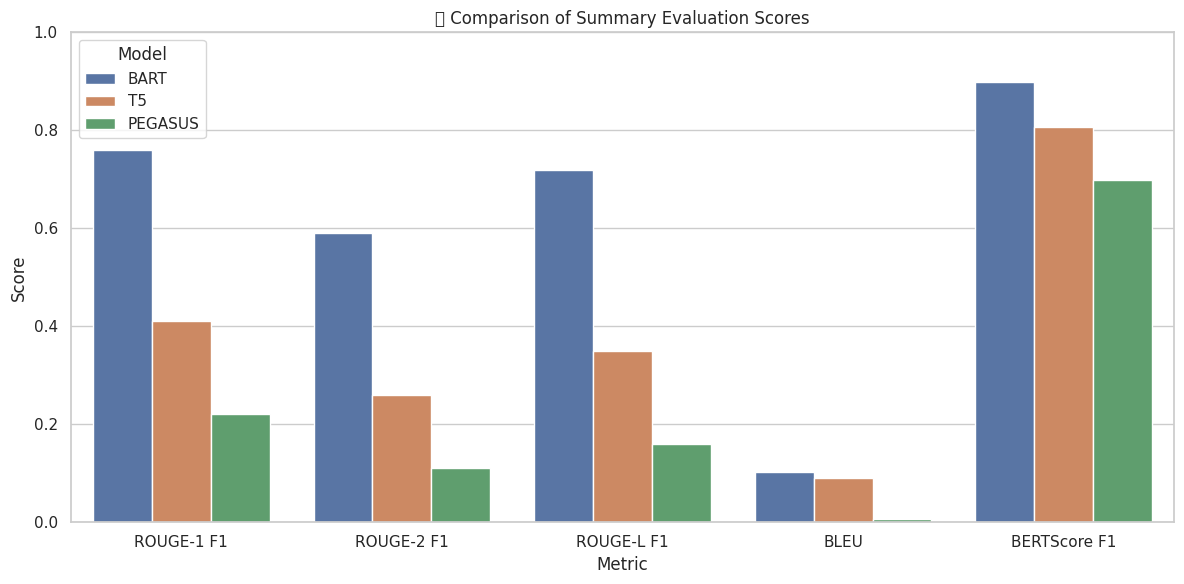

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set(style="whitegrid")

# Sample metrics
data = {
    'Model': ['BART', 'T5', 'PEGASUS'],
    'ROUGE-1 F1': [0.76, 0.41, 0.22],
    'ROUGE-2 F1': [0.59, 0.26, 0.11],
    'ROUGE-L F1': [0.72, 0.35, 0.16],
    'BLEU': [0.1024, 0.0898, 0.0065],
    'BERTScore F1': [0.8992, 0.8077, 0.6978],
    'Perplexity': [1.2586, 2.7809, 4.7839],  # Lower is better
}

df = pd.DataFrame(data)

# Melt for grouped bar charts
melted = df.melt(id_vars="Model", value_vars=['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1', 'BLEU', 'BERTScore F1'], var_name='Metric', value_name='Score')

# Create grouped bar chart for ROUGE, BLEU, BERTScore
plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x="Metric", y="Score", hue="Model")
plt.title("📊 Comparison of Summary Evaluation Scores")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()




<ipython-input-2-d0a7cb028344>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Model', y='Perplexity', palette='muted')
<ipython-input-2-d0a7cb028344>:5: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


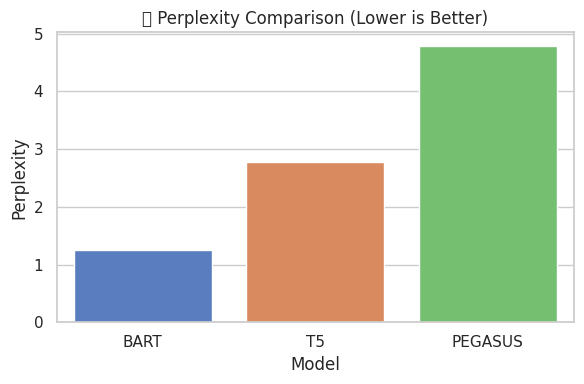

In [ ]:
# Plot Perplexity separately (lower is better)
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Model', y='Perplexity', palette='muted')
plt.title("🔢 Perplexity Comparison (Lower is Better)")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Create DataFrame for Treemap using the provided data
treemap_data = pd.DataFrame({
    "Model": ["BART", "T5", "PEGASUS", "BART", "T5", "PEGASUS", "BART", "T5", "PEGASUS",
              "BART", "T5", "PEGASUS", "BART", "T5", "PEGASUS"],
    "Metric": ["ROUGE-1", "ROUGE-1", "ROUGE-1", "ROUGE-2", "ROUGE-2", "ROUGE-2", "ROUGE-L", "ROUGE-L", "ROUGE-L",
               "BLEU", "BLEU", "BLEU", "BERTScore", "BERTScore", "BERTScore"],
    "Value": [0.76, 0.41, 0.22, 0.59, 0.26, 0.11, 0.72, 0.35, 0.16, 0.1024, 0.0898, 0.0065,
              0.8992, 0.8077, 0.6978]
})

# Create the treemap
fig = px.treemap(treemap_data, path=['Model', 'Metric'], values='Value', color='Value',
                 hover_data=['Value'], color_continuous_scale='RdYlBu')

# Customize the layout
fig.update_layout(title="Treemap of Model Performance")
fig.show()


In [ ]:
import pandas as pd

# Define the data
data = {
    'Model': ['BART', 'T5', 'PEGASUS'],
    'ROUGE-1 F1': [0.76, 0.41, 0.22],
    'ROUGE-2 F1': [0.59, 0.26, 0.11],
    'ROUGE-L F1': [0.72, 0.35, 0.16],
    'BLEU': [0.1024, 0.0898, 0.0065],
    'BERTScore F1': [0.8992, 0.8077, 0.6978]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display the table
print(df)


     Model  ROUGE-1 F1  ROUGE-2 F1  ROUGE-L F1    BLEU  BERTScore F1
0     BART        0.76        0.59        0.72  0.1024        0.8992
1       T5        0.41        0.26        0.35  0.0898        0.8077
2  PEGASUS        0.22        0.11        0.16  0.0065        0.6978


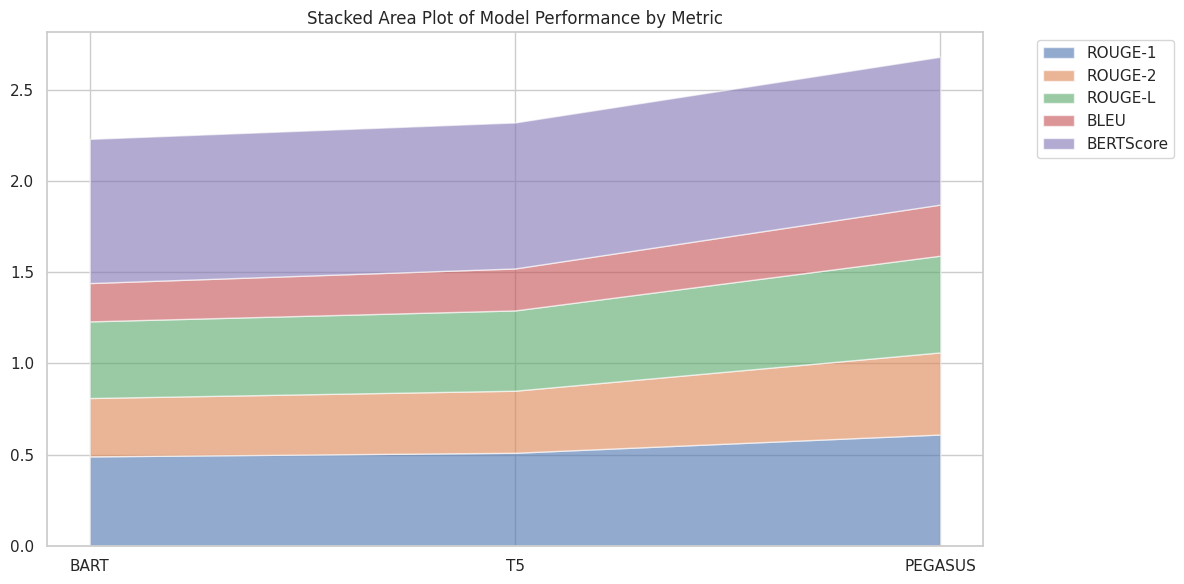

In [ ]:
# Stacked Area Plot
df_metrics = df[metrics]
df_metrics = df_metrics.transpose()

plt.figure(figsize=(12, 6))
plt.stackplot(df['Model'], df_metrics, labels=metrics, alpha=0.6)
plt.title('Stacked Area Plot of Model Performance by Metric')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


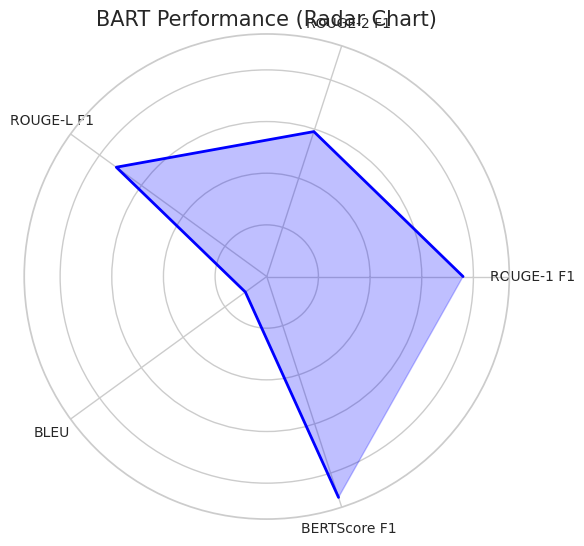

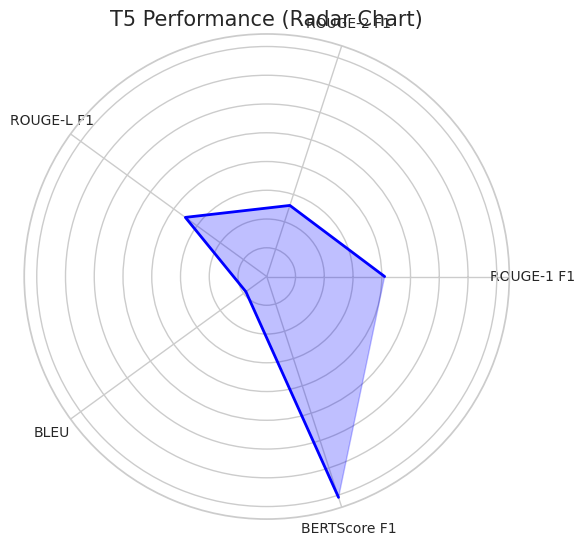

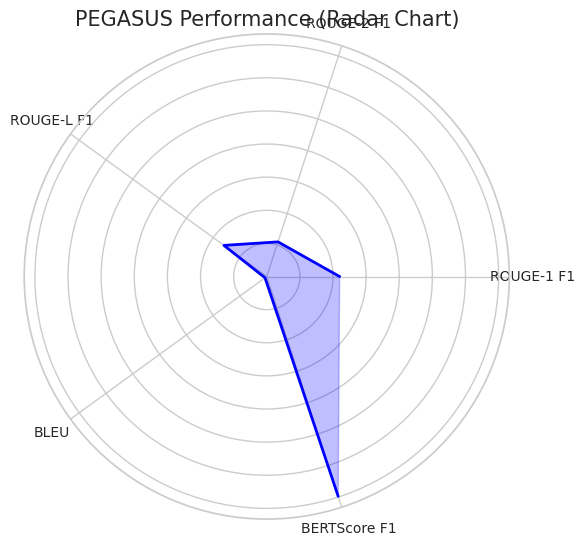

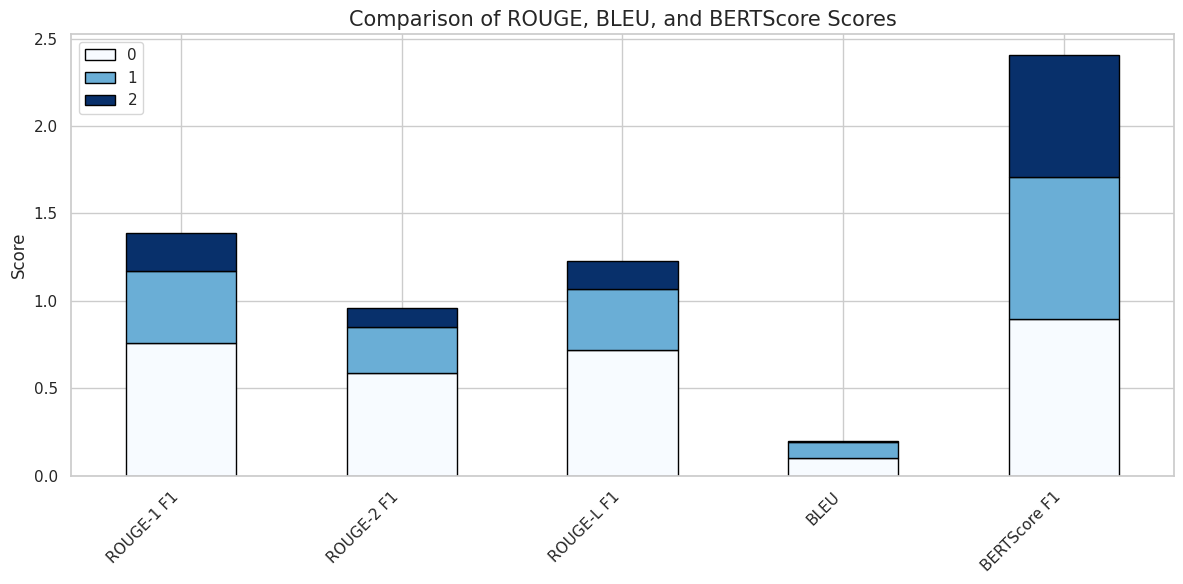

<ipython-input-57-467074cba9bf>:55: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




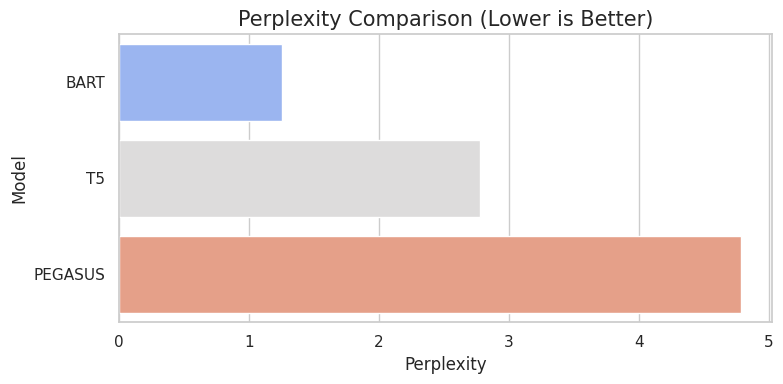

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set style
sns.set(style="whitegrid")

# Sample metrics
data = {
    'Model': ['BART', 'T5', 'PEGASUS'],
    'ROUGE-1 F1': [0.76, 0.41, 0.22],
    'ROUGE-2 F1': [0.59, 0.26, 0.11],
    'ROUGE-L F1': [0.72, 0.35, 0.16],
    'BLEU': [0.1024, 0.0898, 0.0065],
    'BERTScore F1': [0.8992, 0.8077, 0.6978],
    'Perplexity': [1.2586, 2.7809, 4.7839],  # Lower is better
}

df = pd.DataFrame(data)

# Radar Chart (Spider Plot)
def radar_chart(data, metrics, labels, title):
    num_metrics = len(metrics)
    angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
    values = data   # To close the radar chart

    fig, ax = plt.subplots(figsize=(6, 6), dpi=100, subplot_kw=dict(polar=True))
    ax.fill(angles, values, color='blue', alpha=0.25)
    ax.plot(angles, values, color='blue', linewidth=2)
    ax.set_yticklabels([])
    ax.set_xticks(angles)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_title(title, size=15)

    plt.tight_layout()
    plt.show()

# Stacked Bar Plot
def stacked_bar_chart(data, metric_columns, title):
    df_metrics = data[metric_columns]
    df_metrics = df_metrics.transpose()

    ax = df_metrics.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Blues', edgecolor='black')
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title(title, fontsize=15)
    ax.set_xticklabels(metric_columns, rotation=45, ha='right')  # Rotate for better readability
    plt.tight_layout()
    plt.show()


# Horizontal Bar Plot for Perplexity
def horizontal_bar_plot(data, title):
    plt.figure(figsize=(8, 4))
    sns.barplot(data=data, x='Perplexity', y='Model', palette='coolwarm')
    plt.title(title, fontsize=15)
    plt.tight_layout()
    plt.show()

#  Visualizations

# Radar chart for each model across all metrics
for model in df['Model']:
    metrics = ['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1', 'BLEU', 'BERTScore F1']
    values = df[df['Model'] == model][metrics].values.flatten().tolist()
    radar_chart(values, metrics, model, f"{model} Performance (Radar Chart)")

# Stacked Bar Chart for comparing all metrics for models
stacked_bar_chart(df, ['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1', 'BLEU', 'BERTScore F1'], "Comparison of ROUGE, BLEU, and BERTScore Scores")


# Horizontal Bar Plot for Perplexity comparison
horizontal_bar_plot(df, "Perplexity Comparison (Lower is Better)")



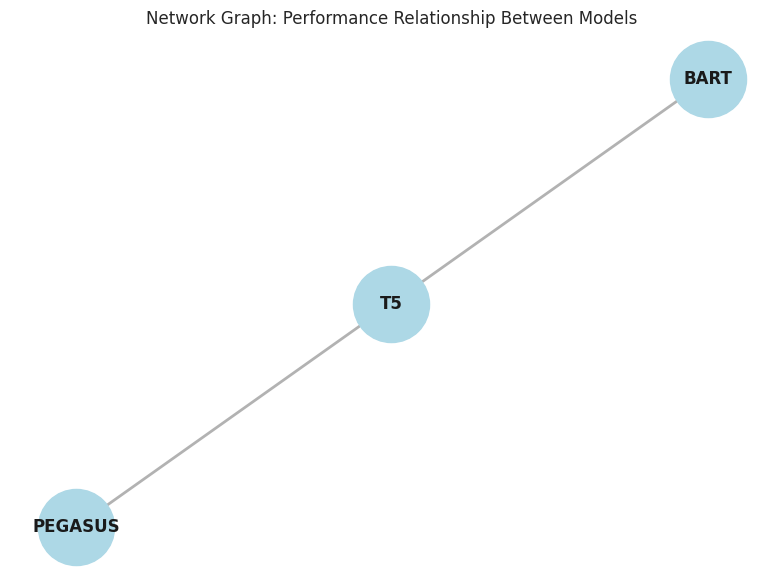

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create a sample dataset with models and their respective scores for different metrics
data = {
    'Model': ['BART', 'T5', 'PEGASUS'],
    'ROUGE-1 F1': [0.76, 0.41, 0.22],
    'ROUGE-2 F1': [0.59, 0.26, 0.11],
    'ROUGE-L F1': [0.72, 0.35, 0.16],
    'BLEU': [0.1024, 0.0898, 0.0065],
    'BERTScore F1': [0.8992, 0.8077, 0.6978],
    #'Perplexity': [1.2586, 2.7809, 4.7839],  # Lower is better
}


df = pd.DataFrame(data)

# Compute pairwise similarity (inverse of distance between models)
from sklearn.metrics.pairwise import cosine_similarity

# Extracting the performance scores
scores = df.drop('Model', axis=1).values

# Compute cosine similarity between models
similarity = cosine_similarity(scores)

# Create a graph
G = nx.Graph()

# Add nodes for each model
for model in df['Model']:
    G.add_node(model)

# Add edges based on similarity (thresholded at 0.9)
threshold = 0.9
for i in range(len(df['Model'])):
    for j in range(i + 1, len(df['Model'])):
        if similarity[i, j] > threshold:
            G.add_edge(df['Model'][i], df['Model'][j], weight=similarity[i, j])

# Draw the network graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # positions for all nodes
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
plt.title('Network Graph: Performance Relationship Between Models')
plt.axis('off')
plt.tight_layout()
plt.show()


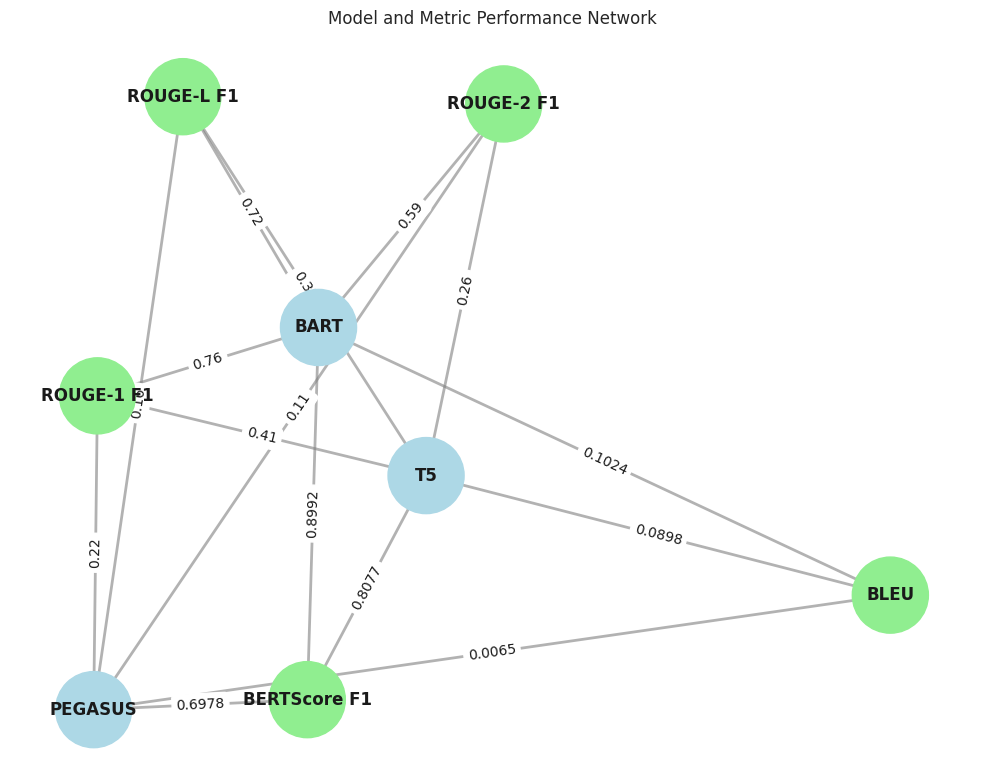

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Define models and metrics
models = ['BART', 'T5', 'PEGASUS']
metrics = ['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1', 'BLEU', 'BERTScore F1']

# Updated performance scores from your provided data
scores = {
    'BART': [0.76, 0.59, 0.72, 0.1024, 0.8992],
    'T5': [0.41, 0.26, 0.35, 0.0898, 0.8077],
    'PEGASUS': [0.22, 0.11, 0.16, 0.0065, 0.6978]
}

# Initialize the graph
G = nx.Graph()

# Add nodes for models and metrics
for model in models:
    G.add_node(model, type='model')
for metric in metrics:
    G.add_node(metric, type='metric')

# Add edges between models and metrics with weights representing performance scores
for model in models:
    for i, metric in enumerate(metrics):
        G.add_edge(model, metric, weight=scores[model][i])

# Draw the network
plt.figure(figsize=(10, 8))

# Set node color based on type (model or metric)
node_color = ['lightblue' if G.nodes[node]['type'] == 'model' else 'lightgreen' for node in G.nodes]

# Draw the graph
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color=node_color)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Add edge labels based on performance scores
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Model and Metric Performance Network')
plt.axis('off')
plt.tight_layout()
plt.show()
